# Notebook 6 — Transformer Model
**Նպատակ:** Transformer (Self-Attention) մեխանիզմով գնի ուղղության կանխատեսում  
**Ենթահարց 6:** Transformer-ի արդյունավետության գնահատում

## 1. Libraries & Load Data

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_score, recall_score
)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D,
    BatchNormalization, Add
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings, os
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
os.chdir('/Users/lusine/Desktop')

with open('data/features/model_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train_seq']
X_val   = data['X_val_seq']
X_test  = data['X_test_seq']
y_train = data['y_train_seq']
y_val   = data['y_val_seq']
y_test  = data['y_test_seq']
N_FEATURES = data['n_features']
SEQ_LEN    = data['SEQUENCE_LEN']

y_train_k = y_train + 1
y_val_k   = y_val   + 1
y_test_k  = y_test  + 1

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (9984, 30, 44)
X_test:  (2116, 30, 44)


## 2. Transformer Architecture
Multi-Head Self-Attention + Feed-Forward blocks

In [2]:
def transformer_encoder_block(x, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
    """Single Transformer Encoder Block."""
    # Multi-Head Self-Attention
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads
    )(x, x)
    attn_output = Dropout(dropout_rate)(attn_output)
    x = LayerNormalization(epsilon=1e-6)(x + attn_output)  # residual

    # Feed-Forward
    ff = Dense(ff_dim, activation='relu')(x)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(embed_dim)(ff)
    ff = Dropout(dropout_rate)(ff)
    x  = LayerNormalization(epsilon=1e-6)(x + ff)  # residual

    return x


def build_transformer(seq_len, n_features, n_classes=3,
                      embed_dim=64, num_heads=4, ff_dim=128,
                      num_blocks=3, dropout=0.2):
    inputs = Input(shape=(seq_len, n_features))

    # Input projection
    x = Dense(embed_dim)(inputs)

    # Transformer blocks
    for _ in range(num_blocks):
        x = transformer_encoder_block(x, embed_dim, num_heads, ff_dim, dropout)

    # Pooling
    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout)(x)

    # Classification head
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)
    outputs = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


transformer_model = build_transformer(SEQ_LEN, N_FEATURES)
transformer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 44)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 64)    │      2,880 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 64)    │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 30, 128)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30, 64)    │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30, 64)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 107,651 (420.51 KB)

 Trainable params: 107,651 (420.51 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [3]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
    ModelCheckpoint('models/transformer_best.keras', save_best_only=True, monitor='val_loss')
]

history = transformer_model.fit(
    X_train, y_train_k,
    validation_data=(X_val, y_val_k),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.3987 - loss: 1.1063 - val_accuracy: 0.3696 - val_loss: 1.0886 - learning_rate: 1.0000e-04
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.4149 - loss: 1.0783 - val_accuracy: 0.4178 - val_loss: 1.0795 - learning_rate: 1.0000e-04
Epoch 3/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.4209 - loss: 1.0728 - val_accuracy: 0.4008 - val_loss: 1.0830 - learning_rate: 1.0000e-04
Epoch 4/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.4228 - loss: 1.0709 - val_accuracy: 0.3852 - val_loss: 1.0805 - learning_rate: 1.0000e-04
Epoch 5/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.4335 - loss: 1.0662 - val_accuracy: 0.3918 - val_loss: 1.0832 - learning_rate: 1.0000e-04
Epoch 6/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.4289 - loss: 1.0656 - val_accuracy: 0.3956 - val_loss: 1.0861 - learning_rate: 1.0000e-04
Epoch 7/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/st

## 4. Training History

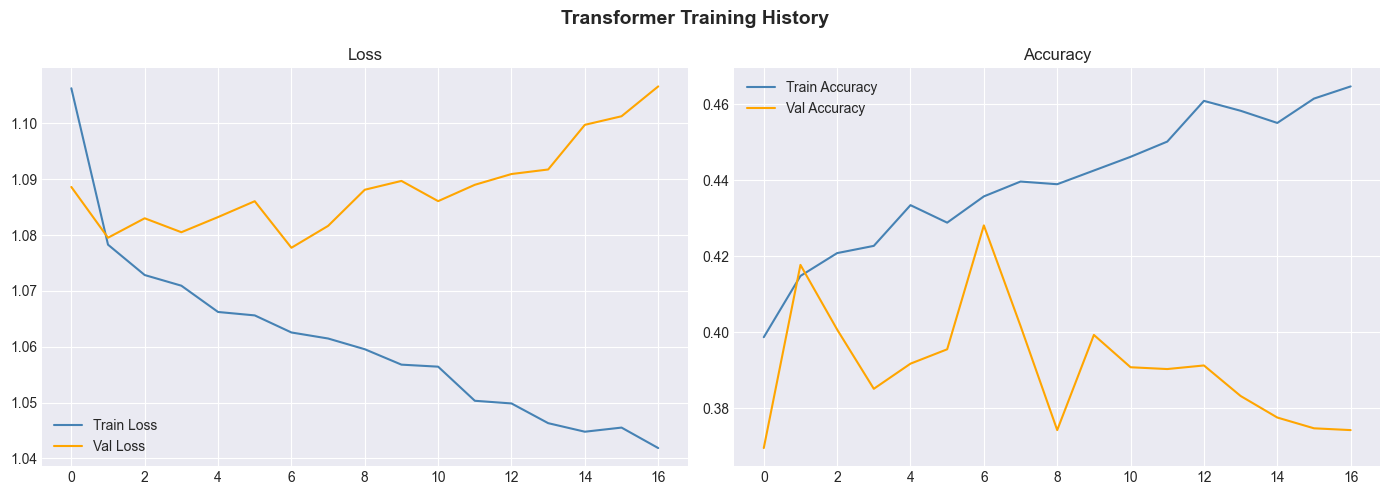

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transformer Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/transformer_training_history.png', dpi=150)
plt.show()

## 5. Evaluation

In [5]:
y_pred_prob = transformer_model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1) - 1

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print('=== Transformer Test Results ===')
print(f'Accuracy:  {acc:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(classification_report(y_test, y_pred, target_names=['Down(-1)', 'Neutral(0)', 'Up(1)']))

transformer_results = {
    'model': 'Transformer',
    'accuracy':  acc,
    'f1':        f1,
    'precision': prec,
    'recall':    rec,
    'y_pred':    y_pred,
    'y_pred_prob': y_pred_prob,
    'history':   history.history
}
with open('results/transformer_results.pkl', 'wb') as f:
    pickle.dump(transformer_results, f)

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
=== Transformer Test Results ===
Accuracy:  0.3979
F1 Score:  0.3977
Precision: 0.3991
Recall:    0.3979
              precision    recall  f1-score   support

    Down(-1)       0.38      0.42      0.40       787
  Neutral(0)       0.39      0.36      0.37       490
       Up(1)       0.42      0.40      0.41       839

    accuracy                           0.40      2116
   macro avg       0.40      0.39      0.39      2116
weighted avg       0.40      0.40      0.40      2116



## 6. Confusion Matrix

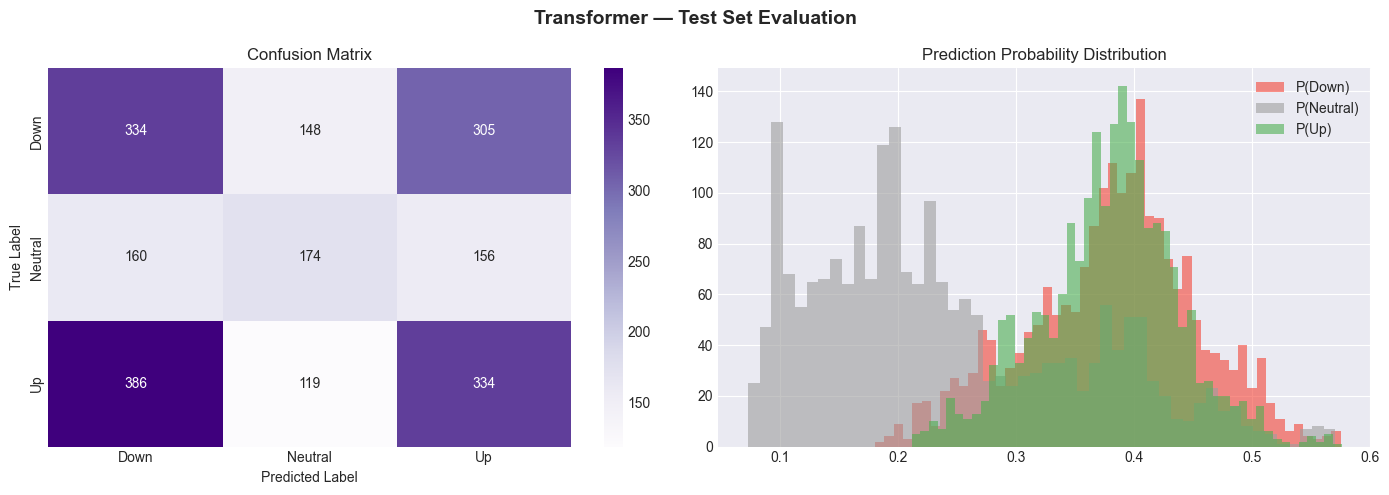

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transformer — Test Set Evaluation', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Down', 'Neutral', 'Up'],
            yticklabels=['Down', 'Neutral', 'Up'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].hist(y_pred_prob[:, 0], bins=50, alpha=0.6, label='P(Down)',    color='#F44336')
axes[1].hist(y_pred_prob[:, 1], bins=50, alpha=0.6, label='P(Neutral)', color='#9E9E9E')
axes[1].hist(y_pred_prob[:, 2], bins=50, alpha=0.6, label='P(Up)',      color='#4CAF50')
axes[1].set_title('Prediction Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/transformer_evaluation.png', dpi=150)
plt.show()

## 7. Attention Weights Visualization
Transformer-ի ամենաուժեղ կողմը — կարող ենք տեսնել ինչ ժամանակային կետերին է ուշադրություն դարձնում։

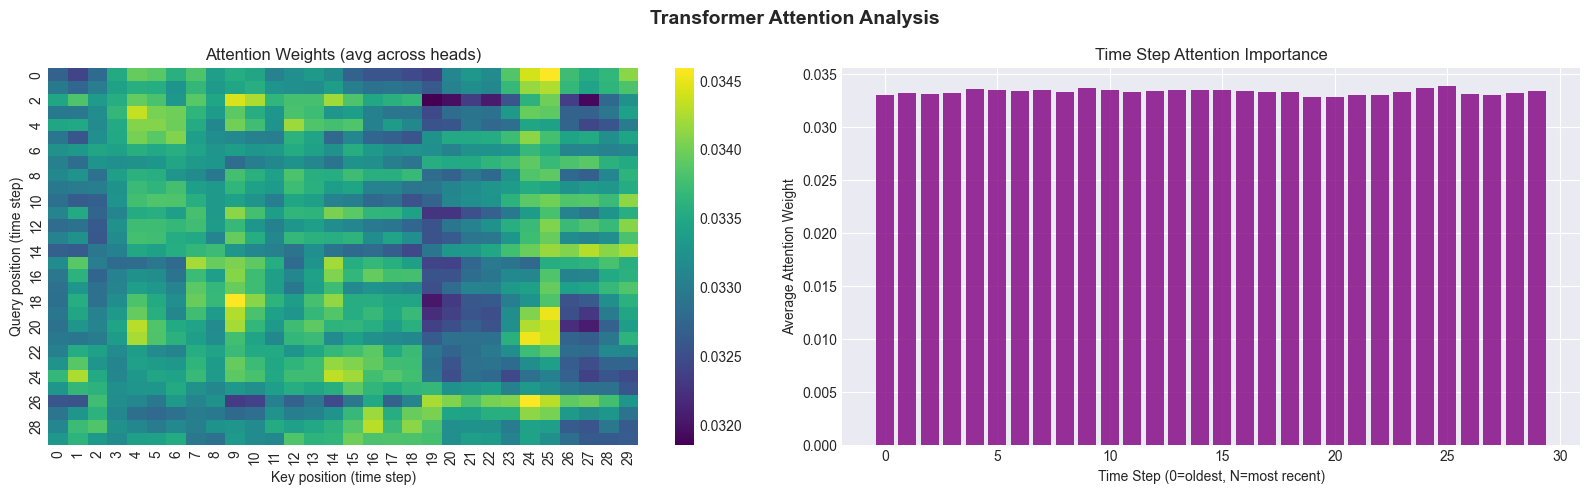

Feature Group Importance:
  Intensity (Q3): +0.0151
  Order Flow (Q1): -0.0043
  Trade Size (Q2): -0.0076
  Technical: -0.0080
  Regime (Q5): -0.0099
  Microstructure (Q4): -0.0288


In [8]:
# Attention Weights Visualization — simplified
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Transformer Attention Analysis', fontsize=14, fontweight='bold')

# Build intermediate model to get attention output
attn_layer_name = [l.name for l in transformer_model.layers if 'multi_head_attention' in l.name][0]
attn_layer = transformer_model.get_layer(attn_layer_name)

# Use a sub-model approach
inp = transformer_model.input
# Get output after Dense projection (before attention)
proj_layer = transformer_model.layers[1]  # Dense projection layer
proj_out = proj_layer(inp)

# Call attention layer directly
attn_out, attn_weights = attn_layer(proj_out, proj_out, return_attention_scores=True)

attn_model = tf.keras.Model(inputs=inp, outputs=attn_weights)

sample_idx = np.random.choice(len(X_test), 1, replace=False)
sample_X   = X_test[sample_idx]
attn_w = attn_model(sample_X, training=False).numpy()  # (1, heads, seq, seq)

# Average across heads
avg_attn = attn_w[0].mean(axis=0)  # (seq, seq)

sns.heatmap(avg_attn, ax=axes[0], cmap='viridis')
axes[0].set_title('Attention Weights (avg across heads)')
axes[0].set_xlabel('Key position (time step)')
axes[0].set_ylabel('Query position (time step)')

attn_importance = avg_attn.mean(axis=0)
axes[1].bar(range(len(attn_importance)), attn_importance, color='purple', alpha=0.8)
axes[1].set_title('Time Step Attention Importance')
axes[1].set_xlabel('Time Step (0=oldest, N=most recent)')
axes[1].set_ylabel('Average Attention Weight')

plt.tight_layout()
plt.savefig('results/transformer_attention.png', dpi=150)
plt.show()

# Feature Group Ablation
FEATURE_GROUPS = {
    'Order Flow (Q1)':      list(range(0, 10)),
    'Trade Size (Q2)':      list(range(10, 18)),
    'Intensity (Q3)':       list(range(18, 28)),
    'Microstructure (Q4)':  list(range(28, 34)),
    'Regime (Q5)':          list(range(34, 39)),
    'Technical':            list(range(39, 44)),
}

group_importance = {}
for group_name, indices in FEATURE_GROUPS.items():
    X_abl = X_test.copy()
    X_abl[:, :, indices] = 0
    y_pred_abl = np.argmax(transformer_model.predict(X_abl, verbose=0), axis=1) - 1
    group_importance[group_name] = acc - accuracy_score(y_test, y_pred_abl)

with open('results/transformer_results.pkl', 'rb') as f:
    tr = pickle.load(f)
tr['group_importance'] = group_importance
with open('results/transformer_results.pkl', 'wb') as f:
    pickle.dump(tr, f)

print('Feature Group Importance:')
for k, v in sorted(group_importance.items(), key=lambda x: -x[1]):
    print(f'  {k}: {v:+.4f}')

**Հաջորդ → Notebook 7: Final Comparison & Results**